# Figure 3f mechanism: T3-FC-referenced networks, matrices and weighted strong-edge allocation

This streamlined notebook asks how the strong-edge backbone is redistributed as FC and IS modularity rise and then fall during training.

All visual comparisons use the **T3 FC network as the only reference**:

- the retained node set is selected once from T3 FC;
- Louvain modules are detected once from T3 FC;
- the Kamada–Kawai node positions are calculated once from T3 FC;
- the matrix node order is calculated once from T3 FC;
- all six FC/IS networks and matrices reuse these objects unchanged.

The T3 FC network uses the same graph, clustering and layout settings as the original Figure 3 code: positive top 40% edges, `min_degree=3`, Louvain resolution 0.75, seed 0, Kamada–Kawai layout and `module_gap=1.5`.

At each sampled training step, positive top-40% edges are split by the fixed T3-FC modules. To include both edge abundance and edge strength without forcing the two curves to sum to one, the plotted weighted allocations are

\[
A_{\mathrm{in}}(t)=\frac{\sum_{(i,j)\in E_{\mathrm{in}}(t)}w_{ij}(t)}{|E_{\mathrm{selected}}(t)|},\qquad
A_{\mathrm{between}}(t)=\frac{\sum_{(i,j)\in E_{\mathrm{between}}(t)}w_{ij}(t)}{|E_{\mathrm{selected}}(t)|}.
\]

Each quantity factorizes as `edge-count fraction × mean edge weight` for that edge class. Their sum is the mean weight of all retained strong edges, not one; therefore the trajectories are not constrained to be mirror images around 0.5.


In [1]:
from pathlib import Path
import json
import random
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore", category=RuntimeWarning)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 7,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
})

COLORS = {
    "FC": "#2E8B57",
    "IS": "#E68632",
    "within": "#3775BA",
    "between": "#D9544D",
    "neutral": "#767676",
    "light": "#D8D8D8",
}

def locate_work_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "FC-IS_code" / "MLP",
        cwd.parent / "FC-IS_code" / "MLP",
    ]
    for candidate in candidates:
        if (candidate / "MLP_FC_IS_analysis.ipynb").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate FC-IS_code/MLP. Start Jupyter from the project root "
        "or from the MLP directory."
    )

WORK_DIR = locate_work_dir()
OUTPUT_DIR = WORK_DIR / "modularity_mechanism_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = WORK_DIR / "modularity_mechanism_cache.npz"

# Figure 3f graph settings.
TOP_PROP = 0.40
POSITIVE_ONLY = True
RESOLUTION = 0.75
COMMUNITY_METHOD = "louvain"
RANDOM_SEED = 0
MIN_DEGREE_PLOT = 3
LAYOUT_TYPE = "kamada"
MODULE_GAP = 1.5

# Connectivity extraction settings. History is sampled every 10 updates.
MODULE_STEP_INTERVAL = 10
MODULE_SAMPLES_PER_CLASS = 100
LAYER_INDEX = 1
REGENERATE_IF_CACHE_MISSING = True

T2, T3, T4 = 130, 320, 1000
STAGES = {"T2": T2, "T3": T3, "T4": T4}

print("Work directory:", WORK_DIR)
print("Output directory:", OUTPUT_DIR)


Work directory: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP
Output directory: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs


## 1. Load or reproduce the FC/IS connectivity history

The cache stores the upper-triangle FC and IS values for the second hidden layer every 10 training steps. If the current kernel already contains `module_steps`, `module_fc_hist` and `module_is_hist`, those arrays are used directly. Otherwise the cache is loaded; if it is missing, the original MNIST MLP configuration is reproduced once and cached.

In [2]:
def save_history_cache(path, steps, fc_history, is_history, metadata):
    np.savez_compressed(
        path,
        steps=np.asarray(steps),
        fc_history=np.asarray(fc_history, dtype=np.float32),
        is_history=np.asarray(is_history, dtype=np.float32),
        metadata=np.asarray(json.dumps(metadata)),
    )


def load_history_cache(path):
    with np.load(path, allow_pickle=False) as data:
        metadata_raw = data["metadata"].item() if "metadata" in data else "{}"
        return (
            np.asarray(data["steps"]),
            np.asarray(data["fc_history"]),
            np.asarray(data["is_history"]),
            json.loads(metadata_raw),
        )


def collect_fixed_balanced_inputs(data_loader, samples_per_class=100, num_classes=10):
    import torch

    class_samples = {class_id: [] for class_id in range(num_classes)}
    for batch_x, batch_y in data_loader:
        for x, y in zip(batch_x, batch_y):
            class_id = int(y)
            if len(class_samples[class_id]) < samples_per_class:
                class_samples[class_id].append(x.detach().cpu().clone())
        if all(len(values) >= samples_per_class for values in class_samples.values()):
            break

    missing = {
        class_id: samples_per_class - len(values)
        for class_id, values in class_samples.items()
        if len(values) < samples_per_class
    }
    if missing:
        raise ValueError("Not enough samples for some classes: " + str(missing))

    return torch.stack([
        x
        for class_id in range(num_classes)
        for x in class_samples[class_id][:samples_per_class]
    ])


def reproduce_history(cache_path=CACHE_PATH):
    try:
        import torch
        import torch.nn as nn
        import torch.nn.init as init
        import torch.optim as optim
        import torchvision
        import torchvision.transforms as transforms
        from torch.utils.data import DataLoader
    except ImportError as exc:
        raise ImportError(
            "The cache is missing and the active kernel does not provide torch/torchvision. "
            "Run this notebook in the same Python environment used for MLP_FC_IS_analysis.ipynb, "
            "or create the cache there first."
        ) from exc

    def set_seed(seed=0):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    class MLP(nn.Module):
        def __init__(
            self,
            input_size=784,
            hidden_dims=(100, 100),
            num_classes=10,
            activation="relu",
            init_method="normal",
            initialize=True,
        ):
            super().__init__()
            self.linear_layers = nn.ModuleList()
            layers = []
            act_map = {
                "relu": nn.ReLU,
                "tanh": nn.Tanh,
                "sigmoid": nn.Sigmoid,
                "leaky_relu": nn.LeakyReLU,
            }
            current_dim = input_size
            for hidden_dim in hidden_dims:
                linear = nn.Linear(current_dim, hidden_dim)
                self.linear_layers.append(linear)
                layers.extend([linear, act_map[activation]()])
                current_dim = hidden_dim
            output = nn.Linear(current_dim, num_classes)
            self.linear_layers.append(output)
            layers.append(output)
            self.network = nn.Sequential(*layers)
            if initialize:
                for module in self.modules():
                    if isinstance(module, nn.Linear):
                        if init_method == "normal":
                            init.normal_(module.weight, mean=0.0, std=0.01)
                        elif init_method == "kaiming":
                            init.kaiming_normal_(module.weight, nonlinearity="relu")
                        elif init_method == "xavier":
                            init.xavier_normal_(module.weight)
                        elif init_method == "orthogonal":
                            init.orthogonal_(module.weight)
                        if module.bias is not None:
                            init.constant_(module.bias, 0.0)

        def forward(self, x):
            return self.network(x.view(x.size(0), -1))

        def get_hidden_activations(self, x):
            x = x.view(x.size(0), -1)
            activations = []
            for layer in self.network:
                x = layer(x)
                if isinstance(layer, (nn.ReLU, nn.Tanh, nn.Sigmoid, nn.LeakyReLU)):
                    activations.append(x.clone())
            return activations

    config = {
        "dataset": "MNIST",
        "input_size": 784,
        "hidden_dims": [100, 100],
        "activation": "relu",
        "init_method": "normal",
        "epochs": 5,
        "batch_size": 256,
        "learning_rate": 0.05,
        "optimizer": "SGD",
        "training_seed": 0,
        "fixed_input_seed": 42,
        "step_interval": MODULE_STEP_INTERVAL,
        "samples_per_class": MODULE_SAMPLES_PER_CLASS,
        "layer_index": LAYER_INDEX,
    }

    set_seed(config["training_seed"])
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    data_root = WORK_DIR / "data"
    train_dataset = torchvision.datasets.MNIST(
        root=str(data_root), train=True, transform=transform, download=True
    )
    test_dataset = torchvision.datasets.MNIST(
        root=str(data_root), train=False, transform=transform, download=True
    )
    train_loader = DataLoader(
        train_dataset, batch_size=config["batch_size"], shuffle=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=config["batch_size"], shuffle=False
    )

    # Match the original: reset the seed immediately before model creation.
    set_seed(config["training_seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLP(
        input_size=config["input_size"],
        hidden_dims=config["hidden_dims"],
        activation=config["activation"],
        init_method=config["init_method"],
    ).to(device)
    optimizer = optim.SGD(model.parameters(), lr=config["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    sampled_steps = []
    sampled_states = []
    snapshot_index = 0
    for epoch in range(config["epochs"]):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            if snapshot_index % config["step_interval"] == 0:
                sampled_steps.append(snapshot_index)
                sampled_states.append({
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                })
            snapshot_index += 1

        # Retained to match the original epoch-level evaluation flow.
        model.eval()
        with torch.no_grad():
            for batch_x, _ in test_loader:
                _ = model(batch_x.to(device))
        print(
            f"epoch {epoch + 1}/{config['epochs']} complete; "
            f"saved snapshots={len(sampled_states)}"
        )

    # Explicit seed removes dependence on notebook execution order.
    fixed_generator = torch.Generator()
    fixed_generator.manual_seed(config["fixed_input_seed"])
    fixed_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        generator=fixed_generator,
    )
    fixed_inputs = collect_fixed_balanced_inputs(
        fixed_loader,
        samples_per_class=config["samples_per_class"],
        num_classes=10,
    )

    template = MLP(
        input_size=config["input_size"],
        hidden_dims=config["hidden_dims"],
        activation=config["activation"],
        init_method=config["init_method"],
        initialize=False,
    ).to(device)
    triu = np.triu_indices(config["hidden_dims"][LAYER_INDEX], k=1)
    fc_history, is_history = [], []

    for state_index, state in enumerate(sampled_states):
        template.load_state_dict(state)
        template.eval()
        weights = (
            template.linear_layers[LAYER_INDEX]
            .weight.detach().cpu().numpy()
        )
        is_matrix = np.nan_to_num(
            np.corrcoef(weights), nan=0.0, posinf=0.0, neginf=0.0
        )

        activation_batches = []
        with torch.no_grad():
            for start in range(0, len(fixed_inputs), 256):
                batch = fixed_inputs[start:start + 256].to(device)
                activations = template.get_hidden_activations(batch)[LAYER_INDEX]
                activation_batches.append(activations.detach().cpu().numpy())
        activation_matrix = np.concatenate(activation_batches, axis=0)
        fc_matrix = np.nan_to_num(
            np.corrcoef(activation_matrix.T),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )
        fc_history.append(fc_matrix[triu])
        is_history.append(is_matrix[triu])
        if state_index % 20 == 0:
            print(f"connectivity extraction {state_index + 1}/{len(sampled_states)}")

    metadata = {
        **config,
        "device": str(device),
        "note": (
            "Reproduces the Figure 3f model settings; fixed FC inputs use an "
            "explicit seed to remove cell-order dependence."
        ),
    }
    save_history_cache(
        cache_path,
        sampled_steps,
        np.asarray(fc_history),
        np.asarray(is_history),
        metadata,
    )
    return (
        np.asarray(sampled_steps),
        np.asarray(fc_history),
        np.asarray(is_history),
        metadata,
    )


if all(name in globals() for name in ["module_steps", "module_fc_hist", "module_is_hist"]):
    steps = np.asarray(module_steps)
    fc_history = np.asarray(module_fc_hist)
    is_history = np.asarray(module_is_hist)
    history_metadata = {"source": "current kernel variables"}
elif CACHE_PATH.exists():
    steps, fc_history, is_history, history_metadata = load_history_cache(CACHE_PATH)
elif REGENERATE_IF_CACHE_MISSING:
    steps, fc_history, is_history, history_metadata = reproduce_history(CACHE_PATH)
else:
    raise FileNotFoundError(
        f"No connectivity-history cache found at {CACHE_PATH}. "
        "Set REGENERATE_IF_CACHE_MISSING=True or provide module_* variables."
    )

if fc_history.shape != is_history.shape:
    raise ValueError("FC and IS histories have different shapes.")
if len(steps) != len(fc_history):
    raise ValueError("Step vector and connectivity histories have different lengths.")

print("History shapes:", steps.shape, fc_history.shape, is_history.shape)
print("History metadata:", json.dumps(history_metadata, indent=2))

History shapes: (118,) (118, 4950) (118, 4950)
History metadata: {
  "dataset": "MNIST",
  "input_size": 784,
  "hidden_dims": [
    100,
    100
  ],
  "activation": "relu",
  "init_method": "normal",
  "epochs": 5,
  "batch_size": 256,
  "learning_rate": 0.05,
  "optimizer": "SGD",
  "training_seed": 0,
  "fixed_input_seed": 42,
  "step_interval": 10,
  "samples_per_class": 100,
  "layer_index": 1,
  "device": "cuda",
  "note": "Reproduces the Figure 3f model settings; fixed FC inputs use an explicit seed to remove cell-order dependence."
}


## 2. Reproduce the original T3-FC network and freeze the reference

`reference_nodes`, `reference_communities`, `reference_positions` and `reference_order` are calculated once below. The T3-FC graph and layout code deliberately mirrors the original notebook. Other stages and IS replace only the edge set and weights.

In [3]:
def infer_node_count(vector_length):
    n_nodes = int((1 + np.sqrt(1 + 8 * vector_length)) / 2)
    if n_nodes * (n_nodes - 1) // 2 != vector_length:
        raise ValueError(f"Invalid upper-triangle length: {vector_length}")
    return n_nodes


def vector_to_matrix(vector):
    vector = np.asarray(vector, dtype=float)
    n_nodes = infer_node_count(vector.size)
    matrix = np.zeros((n_nodes, n_nodes), dtype=float)
    triu = np.triu_indices(n_nodes, k=1)
    matrix[triu] = vector
    matrix[(triu[1], triu[0])] = vector
    return matrix


def nearest_index(values, target):
    return int(np.argmin(np.abs(np.asarray(values) - target)))


def build_graph_top_edges(matrix, top_prop=0.40, positive_only=True):
    # Exact graph-construction rule used in the original Figure 3 code.
    matrix = np.asarray(matrix, dtype=float).copy()
    matrix[~np.isfinite(matrix)] = 0.0
    np.fill_diagonal(matrix, 0.0)
    n_nodes = matrix.shape[0]
    graph = nx.Graph()
    graph.add_nodes_from(range(n_nodes))
    triu = np.triu_indices(n_nodes, k=1)
    values = matrix[triu]
    rows, cols = triu
    if positive_only:
        mask = values > 0
        values = values[mask]
        rows, cols = rows[mask], cols[mask]
    if len(values) == 0:
        return graph, np.nan
    n_keep = min(max(int(np.ceil(len(values) * top_prop)), 1), len(values))
    top_idx = np.argsort(values)[-n_keep:]
    graph.add_weighted_edges_from([
        (int(rows[index]), int(cols[index]), float(values[index]))
        for index in top_idx
    ])
    return graph, float(np.min(values[top_idx]))


def detect_communities(graph, method="louvain", resolution=1.0, seed=0):
    if graph.number_of_edges() == 0:
        communities = [{node} for node in graph.nodes()]
        return communities, {node: i for i, node in enumerate(graph.nodes())}, 0.0
    if method == "louvain" and hasattr(nx.community, "louvain_communities"):
        communities = list(nx.community.louvain_communities(
            graph, weight="weight", resolution=resolution, seed=seed
        ))
    else:
        communities = list(nx.community.greedy_modularity_communities(
            graph, weight="weight", resolution=resolution
        ))
    node_to_community = {
        node: community_index
        for community_index, community in enumerate(communities)
        for node in community
    }
    q_value = nx.community.modularity(
        graph, communities, weight="weight", resolution=resolution
    ) if len(communities) > 1 else 0.0
    return communities, node_to_community, float(q_value)


def get_topology_layout(
    graph,
    layout_type="kamada",
    seed=0,
    community_method="louvain",
    resolution=1.0,
    module_gap=3.0,
):
    # Exact T3-FC layout logic from MLP_FC_IS_analysis.ipynb.
    if layout_type == "kamada":
        _, node_to_community, _ = detect_communities(
            graph,
            method=community_method,
            resolution=resolution,
            seed=seed,
        )
        distance_graph = nx.Graph()
        distance_graph.add_nodes_from(graph.nodes())
        for u, v, data in graph.edges(data=True):
            similarity = max(float(data.get("weight", 1.0)), 1e-6)
            distance = 1.0 / similarity
            if node_to_community[u] != node_to_community[v]:
                distance *= module_gap
            distance_graph.add_edge(u, v, distance=distance)
        distances = dict(nx.all_pairs_dijkstra_path_length(
            distance_graph, weight="distance"
        ))
        return nx.kamada_kawai_layout(
            graph, dist=distances, weight=None, scale=1.0
        )
    if layout_type == "spring":
        return nx.spring_layout(
            graph, weight="weight", seed=seed, iterations=300
        )
    if layout_type == "spectral":
        return nx.spectral_layout(graph, weight="weight")
    if layout_type == "circular":
        return nx.circular_layout(graph)
    return nx.kamada_kawai_layout(graph)


def t3_fc_reference_order(communities, positions, t3_fc_matrix):
    # Order modules and nodes using their positions in the T3-FC layout.
    ordered_communities = sorted(
        [set(community) for community in communities],
        key=lambda community: np.mean([positions[node][0] for node in community]),
    )
    order, boundaries = [], []
    for community in ordered_communities:
        nodes = np.asarray(sorted(community), dtype=int)
        if len(nodes) > 2:
            similarity = np.clip(t3_fc_matrix[np.ix_(nodes, nodes)], -1.0, 1.0)
            distance = 1.0 - similarity
            distance = (distance + distance.T) / 2.0
            np.fill_diagonal(distance, 0.0)
            linkage = hierarchy.linkage(
                squareform(distance, checks=False), method="average"
            )
            nodes = nodes[hierarchy.leaves_list(linkage)]
        order.extend(nodes.tolist())
        boundaries.append(len(order))
    return np.asarray(order, dtype=int), boundaries[:-1], ordered_communities


# Construct the T3 FC graph once.
t3_index = nearest_index(steps, T3)
t3_fc_matrix = vector_to_matrix(fc_history[t3_index])
t3_fc_graph_full, t3_fc_threshold = build_graph_top_edges(
    t3_fc_matrix, top_prop=TOP_PROP, positive_only=POSITIVE_ONLY
)
reference_nodes = [
    node for node, degree in t3_fc_graph_full.degree()
    if degree >= MIN_DEGREE_PLOT
]
t3_fc_graph = t3_fc_graph_full.subgraph(reference_nodes).copy()
reference_communities, reference_node_to_community, reference_q = detect_communities(
    t3_fc_graph,
    method=COMMUNITY_METHOD,
    resolution=RESOLUTION,
    seed=RANDOM_SEED,
)
reference_positions = get_topology_layout(
    t3_fc_graph,
    layout_type=LAYOUT_TYPE,
    seed=RANDOM_SEED,
    community_method=COMMUNITY_METHOD,
    resolution=RESOLUTION,
    module_gap=MODULE_GAP,
)
reference_order, reference_boundaries, ordered_reference_communities = (
    t3_fc_reference_order(
        reference_communities, reference_positions, t3_fc_matrix
    )
)

print(
    f"T3 FC reference | step={steps[t3_index]} | nodes={len(reference_nodes)} | "
    f"edges={t3_fc_graph.number_of_edges()} | threshold={t3_fc_threshold:.4f} | "
    f"Q={reference_q:.4f} | modules={len(reference_communities)}"
)

T3 FC reference | step=320 | nodes=88 | edges=914 | threshold=0.6272 | Q=0.6247 | modules=4


## 3. Six paired network and adjacency-matrix views

Each matrix is the weighted adjacency matrix of the exact graph drawn above it: selected edges retain their FC/IS weight and absent edges are white. FC panels share one color scale and IS panels share another. Black lines mark the fixed T3-FC module boundaries.

/mnt/Data16T/home/haichao/miniconda3/envs/neuroai/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


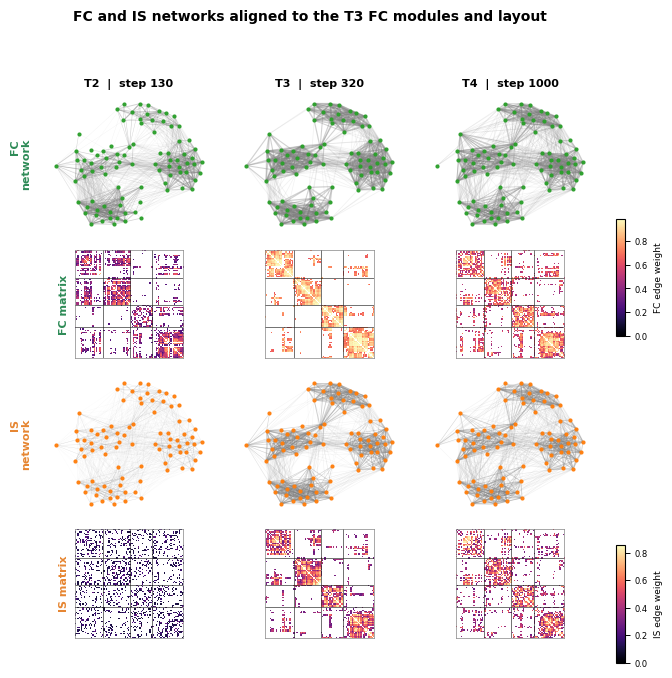

/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_T3FC_reference_networks_heatmaps.svg
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_T3FC_reference_networks_heatmaps.pdf
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_T3FC_reference_networks_heatmaps.tiff
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_T3FC_reference_networks_heatmaps.png


In [20]:
def stage_graphs_from_history(history):
    output = {}
    for stage_name, target_step in STAGES.items():
        index = nearest_index(steps, target_step)
        matrix = vector_to_matrix(history[index])
        graph, threshold = build_graph_top_edges(
            matrix, top_prop=TOP_PROP, positive_only=POSITIVE_ONLY
        )
        output[stage_name] = {
            "index": index,
            "step": int(steps[index]),
            "matrix": matrix,
            "graph": graph.subgraph(reference_nodes).copy(),
            "threshold": threshold,
        }
    return output


stage_graphs = {
    "FC": stage_graphs_from_history(fc_history),
    "IS": stage_graphs_from_history(is_history),
}


def draw_original_style_reference_network(ax, graph, network_kind):
    # Original edge widths/alpha/node style; fixed T3-FC positions and modules.
    positions = {node: reference_positions[node] for node in graph.nodes()}
    within_edges, between_edges = [], []
    for u, v in graph.edges():
        if reference_node_to_community[u] == reference_node_to_community[v]:
            within_edges.append((u, v))
        else:
            between_edges.append((u, v))
    within_widths = [
        0 + 1.2 * graph[u][v].get("weight", 1.0)
        for u, v in within_edges
    ]
    between_widths = [
        0 + 0.8 * graph[u][v].get("weight", 1.0)
        for u, v in between_edges
    ]
    nx.draw_networkx_edges(
        graph, positions, edgelist=between_edges, ax=ax,
        width=between_widths, alpha=0.10, edge_color="gray"
    )
    nx.draw_networkx_edges(
        graph, positions, edgelist=within_edges, ax=ax,
        width=within_widths, alpha=0.35, edge_color="gray"
    )
    nx.draw_networkx_nodes(
        graph, positions, ax=ax, node_size=4,
        node_color="tab:green" if network_kind == "FC" else "tab:orange",
        cmap=plt.cm.Paired, alpha=0.95
    )
    ax.set_axis_off()


def graph_adjacency_in_reference_order(graph):
    return nx.to_numpy_array(
        graph,
        nodelist=reference_order.tolist(),
        weight="weight",
        nonedge=0.0,
    )


heatmap_vmax = {}
for network_kind in ["FC", "IS"]:
    values = []
    for stage_name in STAGES:
        matrix = graph_adjacency_in_reference_order(
            stage_graphs[network_kind][stage_name]["graph"]
        )
        values.extend(matrix[matrix > 0].tolist())
    heatmap_vmax[network_kind] = float(np.quantile(values, 0.995))


fig = plt.figure(figsize=(7.2, 7.1))
outer = fig.add_gridspec(
    4, 3,
    height_ratios=[1.35, 1.0, 1.35, 1.0],
    hspace=0.10, wspace=0.08,
)
heatmap_images = {}

for network_row, network_kind in enumerate(["FC", "IS"]):
    network_grid_row = 2 * network_row
    matrix_grid_row = network_grid_row + 1
    for column, stage_name in enumerate(STAGES):
        record = stage_graphs[network_kind][stage_name]
        ax_network = fig.add_subplot(outer[network_grid_row, column])
        draw_original_style_reference_network(
            ax_network, record["graph"], network_kind
        )
        if network_row == 0:
            ax_network.set_title(
                f"{stage_name}  |  step {record['step']}",
                fontsize=8, fontweight="bold", pad=3
            )
        if column == 0:
            ax_network.text(
                -0.05, 0.5, f"{network_kind}\nnetwork",
                transform=ax_network.transAxes,
                rotation=90, ha="right", va="center",
                color=COLORS[network_kind], fontsize=8, fontweight="bold"
            )

        ax_matrix = fig.add_subplot(outer[matrix_grid_row, column])
        adjacency = graph_adjacency_in_reference_order(record["graph"])
        masked = np.ma.masked_where(adjacency <= 0, adjacency)
        cmap = mpl.colormaps["magma"].copy()
        cmap.set_bad("white")
        image = ax_matrix.imshow(
            masked, cmap=cmap, vmin=0,
            vmax=heatmap_vmax[network_kind],
            interpolation="nearest", aspect="equal"
        )
        heatmap_images[network_kind] = image
        for boundary in reference_boundaries:
            ax_matrix.axhline(boundary - 0.5, color="#222222", lw=0.45)
            ax_matrix.axvline(boundary - 0.5, color="#222222", lw=0.45)
        ax_matrix.set_xticks([])
        ax_matrix.set_yticks([])
        for spine in ax_matrix.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.45)
            spine.set_color("#777777")
        if column == 0:
            ax_matrix.set_ylabel(
                f"{network_kind} matrix",
                color=COLORS[network_kind], fontsize=8, fontweight="bold"
            )

# Stable row-specific color bars that do not alter the panel widths.
cax_fc = fig.add_axes([0.925, 0.535, 0.012, 0.165])
cbar_fc = fig.colorbar(heatmap_images["FC"], cax=cax_fc)
cbar_fc.set_label("FC edge weight", fontsize=6.5)
cbar_fc.ax.tick_params(labelsize=6)
cax_is = fig.add_axes([0.925, 0.075, 0.012, 0.165])
cbar_is = fig.colorbar(heatmap_images["IS"], cax=cax_is)
cbar_is.set_label("IS edge weight", fontsize=6.5)
cbar_is.ax.tick_params(labelsize=6)

fig.suptitle(
    "FC and IS networks aligned to the T3 FC modules and layout",
    y=0.995, fontsize=10, fontweight="bold"
)

def save_publication_figure(fig, stem):
    paths = []
    for extension, kwargs in [
        ("svg", {}), ("pdf", {}),
        ("tiff", {"dpi": 600}), ("png", {"dpi": 250}),
    ]:
        path = OUTPUT_DIR / f"{stem}.{extension}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        paths.append(path)
    return paths

network_matrix_paths = save_publication_figure(
    fig, "Figure3f_T3FC_reference_networks_heatmaps"
)
plt.show()
print("\n".join(map(str, network_matrix_paths)))

## 4. Weighted within- and between-module strong-edge allocation every 10 steps

The T3-FC node set and module labels remain fixed. At each sampled step, FC and IS graphs are rebuilt using the same positive-top-40% rule.

For each edge class, the sum of retained edge weights is divided by the total number of retained edges. Thus, the plotted quantity increases when that class contains more selected edges, stronger selected edges, or both. Unlike a proportion normalized by total weight, the within- and between-module curves are not forced to sum to one.


In [5]:
def reference_weighted_allocation_metrics(graph):
    graph = graph.subgraph(reference_nodes).copy()
    within_count = 0
    between_count = 0
    within_weight = 0.0
    between_weight = 0.0

    for u, v, data in graph.edges(data=True):
        weight = float(data.get("weight", 1.0))
        if reference_node_to_community[u] == reference_node_to_community[v]:
            within_count += 1
            within_weight += weight
        else:
            between_count += 1
            between_weight += weight

    selected_edge_count = within_count + between_count
    total_selected_weight = within_weight + between_weight

    if selected_edge_count == 0:
        edge_fraction_within = np.nan
        edge_fraction_between = np.nan
        mean_weight_within = np.nan
        mean_weight_between = np.nan
        weighted_allocation_within = np.nan
        weighted_allocation_between = np.nan
        mean_selected_edge_weight = np.nan
    else:
        edge_fraction_within = within_count / selected_edge_count
        edge_fraction_between = between_count / selected_edge_count
        mean_weight_within = within_weight / within_count if within_count else 0.0
        mean_weight_between = between_weight / between_count if between_count else 0.0
        weighted_allocation_within = within_weight / selected_edge_count
        weighted_allocation_between = between_weight / selected_edge_count
        mean_selected_edge_weight = total_selected_weight / selected_edge_count

    communities = [set(community) for community in reference_communities]
    q_reference = nx.community.modularity(
        graph, communities, weight="weight", resolution=RESOLUTION
    ) if graph.number_of_edges() else 0.0

    return {
        "selected_edge_count": selected_edge_count,
        "edge_count_within": within_count,
        "edge_count_between": between_count,
        "edge_fraction_within": edge_fraction_within,
        "edge_fraction_between": edge_fraction_between,
        "weight_sum_within": within_weight,
        "weight_sum_between": between_weight,
        "mean_weight_within": mean_weight_within,
        "mean_weight_between": mean_weight_between,
        "weighted_allocation_within": weighted_allocation_within,
        "weighted_allocation_between": weighted_allocation_between,
        "mean_selected_edge_weight": mean_selected_edge_weight,
        "q_T3FC_partition": q_reference,
    }


def compute_weighted_allocation_history(network_kind, history):
    records = []
    for step, vector in zip(steps, history):
        matrix = vector_to_matrix(vector)
        graph, threshold = build_graph_top_edges(
            matrix, top_prop=TOP_PROP, positive_only=POSITIVE_ONLY
        )
        records.append({
            "network": network_kind,
            "step": int(step),
            "threshold": threshold,
            **reference_weighted_allocation_metrics(graph),
        })
    return pd.DataFrame(records)


weighted_allocation_history = pd.concat([
    compute_weighted_allocation_history("FC", fc_history),
    compute_weighted_allocation_history("IS", is_history),
], ignore_index=True)

# Exact identities used as internal checks.
allocation_sum = (
    weighted_allocation_history["weighted_allocation_within"]
    + weighted_allocation_history["weighted_allocation_between"]
)
if not np.allclose(
    allocation_sum.dropna(),
    weighted_allocation_history.loc[
        allocation_sum.notna(), "mean_selected_edge_weight"
    ],
    atol=1e-12,
):
    raise AssertionError("Weighted allocations do not recover the mean selected-edge weight.")

within_factorization = (
    weighted_allocation_history["edge_fraction_within"]
    * weighted_allocation_history["mean_weight_within"]
)
between_factorization = (
    weighted_allocation_history["edge_fraction_between"]
    * weighted_allocation_history["mean_weight_between"]
)
if not np.allclose(
    within_factorization.fillna(0.0),
    weighted_allocation_history["weighted_allocation_within"].fillna(0.0),
    atol=1e-12,
) or not np.allclose(
    between_factorization.fillna(0.0),
    weighted_allocation_history["weighted_allocation_between"].fillna(0.0),
    atol=1e-12,
):
    raise AssertionError("Count-fraction × mean-weight factorization failed.")

weighted_allocation_history.to_csv(
    OUTPUT_DIR / "Figure3f_within_between_weighted_allocation_source_data.csv",
    index=False,
)

display(weighted_allocation_history.head().round(6))


,network,step,threshold,selected_edge_count,edge_count_within,edge_count_between,edge_fraction_within,edge_fraction_between,weight_sum_within,weight_sum_between,mean_weight_within,mean_weight_between,weighted_allocation_within,weighted_allocation_between,mean_selected_edge_weight,q_T3FC_partition
0,FC,0,0.118632,874,306,568,0.350114,0.649886,70.124391,119.213591,0.229165,0.209883,0.080234,0.136400,0.216634,0.174620
1,FC,10,0.120038,885,323,562,0.364972,0.635028,75.454164,118.514489,0.233604,0.210880,0.085259,0.133915,0.219174,0.192422
2,FC,20,0.121912,895,337,558,0.376536,0.623464,81.138121,118.404662,0.240766,0.212195,0.090657,0.132296,0.222953,0.209943
3,FC,30,0.125798,900,352,548,0.391111,0.608889,88.028444,118.499579,0.250081,0.216240,0.097809,0.131666,0.229476,0.228619
4,FC,40,0.128462,912,374,538,0.410088,0.589912,96.960355,119.157581,0.259252,0.221482,0.106316,0.130655,0.236971,0.249405


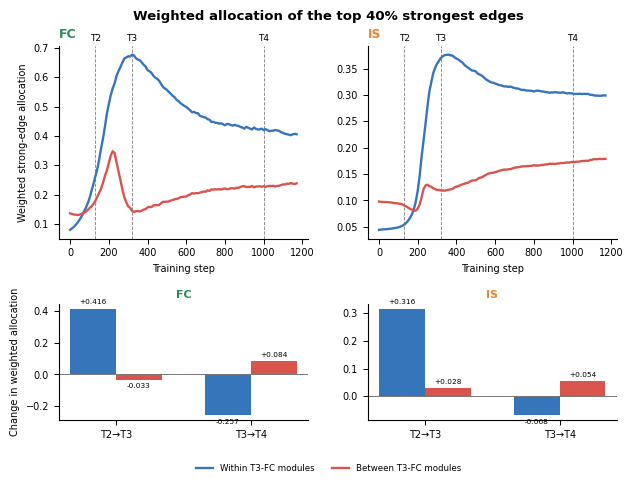

/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_within_between_weighted_allocation_dynamics.svg
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_within_between_weighted_allocation_dynamics.pdf
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_within_between_weighted_allocation_dynamics.tiff
/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/modularity_mechanism_outputs/Figure3f_within_between_weighted_allocation_dynamics.png


,network,phase,start_step,end_step,delta_within,delta_between
0,FC,T2 to T3,130,320,0.416168,-0.033429
1,FC,T3 to T4,320,1000,-0.257033,0.084129
2,IS,T2 to T3,130,320,0.315731,0.028420
3,IS,T3 to T4,320,1000,-0.067532,0.053850


In [21]:
def add_stage_lines(ax, max_step):
    for stage_name, stage_step in STAGES.items():
        if stage_step <= max_step:
            ax.axvline(
                stage_step, color="#888888", lw=0.65, ls="--", zorder=0
            )
            ax.text(
                stage_step, 1.015, stage_name,
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=6.5,
            )


def weighted_allocation_phase_changes(history_table):
    phase_specs = [
        ("T2 to T3", T2, T3),
        ("T3 to T4", T3, T4),
    ]
    records = []
    for network_kind in ["FC", "IS"]:
        table = history_table.query(
            "network == @network_kind"
        ).reset_index(drop=True)
        for phase_name, start_target, end_target in phase_specs:
            start_row = table.iloc[nearest_index(table["step"], start_target)]
            end_row = table.iloc[nearest_index(table["step"], end_target)]
            records.append({
                "network": network_kind,
                "phase": phase_name,
                "start_step": int(start_row["step"]),
                "end_step": int(end_row["step"]),
                "delta_within": (
                    end_row["weighted_allocation_within"]
                    - start_row["weighted_allocation_within"]
                ),
                "delta_between": (
                    end_row["weighted_allocation_between"]
                    - start_row["weighted_allocation_between"]
                ),
            })
    return pd.DataFrame(records)


phase_changes = weighted_allocation_phase_changes(weighted_allocation_history)
phase_changes.to_csv(
    OUTPUT_DIR / "Figure3f_weighted_allocation_phase_changes.csv",
    index=False,
)

global_curve_max = np.nanmax(
    weighted_allocation_history[[
        "weighted_allocation_within", "weighted_allocation_between"
    ]].to_numpy()
)
global_bar_max = np.nanmax(np.abs(
    phase_changes[["delta_within", "delta_between"]].to_numpy()
))
bar_limit = max(global_bar_max * 1.25, 0.01)

fig = plt.figure(figsize=(7.2, 4.8))
grid = fig.add_gridspec(
    2, 2,
    height_ratios=[1.65, 1.0],
    hspace=0.42,
    wspace=0.24,
)

curve_axes = []
for column, network_kind in enumerate(["FC", "IS"]):
    ax = fig.add_subplot(grid[0, column])
    curve_axes.append(ax)
    table = weighted_allocation_history.query(
        "network == @network_kind"
    ).reset_index(drop=True)
    x = table["step"].to_numpy()

    ax.plot(
        x, table["weighted_allocation_within"].to_numpy(),
        color=COLORS["within"], lw=1.7,
        label="Within T3-FC modules",
    )
    ax.plot(
        x, table["weighted_allocation_between"].to_numpy(),
        color=COLORS["between"], lw=1.7,
        label="Between T3-FC modules",
    )
    add_stage_lines(ax, int(x.max()))
    # ax.set_ylim(0.0, global_curve_max * 1.08)
    ax.set_xlabel("Training step")
    ax.set_title(
        network_kind, color=COLORS[network_kind],
        fontsize=9, fontweight="bold", loc="left",
    )
    if column == 0:
        ax.set_ylabel("Weighted strong-edge allocation")
    # else:
        # ax.tick_params(labelleft=False)


# bar_axes = []
# for column, phase_name in enumerate(["T2 to T3", "T3 to T4"]):
#     ax = fig.add_subplot(grid[1, column])
#     bar_axes.append(ax)
#     phase_table = (
#         phase_changes.query("phase == @phase_name")
#         .set_index("network")
#         .loc[["FC", "IS"]]
#     )
#     x = np.arange(2)
#     width = 0.34
#     bars_within = ax.bar(
#         x - width / 2,
#         phase_table["delta_within"].to_numpy(),
#         width=width, color=COLORS["within"],
#     )
#     bars_between = ax.bar(
#         x + width / 2,
#         phase_table["delta_between"].to_numpy(),
#         width=width, color=COLORS["between"],
#     )
#     ax.axhline(0.0, color="#777777", lw=0.7)
#     ax.set_xticks(x, ["FC", "IS"])
#     # ax.set_ylim(-bar_limit, bar_limit)
#     ax.set_title(phase_name, fontsize=8, fontweight="bold", pad=4)
#     if column == 0:
#         ax.set_ylabel("Change in weighted allocation")
#     # else:
#     #     ax.tick_params(labelleft=False)

#     for bars in [bars_within, bars_between]:
#         for bar in bars:
#             value = float(bar.get_height())
#             offset = 2.5 if value >= 0 else -2.5
#             ax.annotate(
#                 f"{value:+.3f}",
#                 xy=(bar.get_x() + bar.get_width() / 2, value),
#                 xytext=(0, offset), textcoords="offset points",
#                 ha="center",
#                 va="bottom" if value >= 0 else "top",
#                 fontsize=5.3,
#             )

# fig.suptitle(
#     "Weighted allocation of the top 40% strongest edges",
#     y=0.985, fontsize=9.5, fontweight="bold",
# )
# handles, labels = curve_axes[0].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     loc="lower center", bbox_to_anchor=(0.5, 0.005),
#     ncol=2, fontsize=6.2,
# )
# fig.subplots_adjust(bottom=0.13, top=0.91)

# curve_paths = save_publication_figure(
#     fig, "Figure3f_within_between_weighted_allocation_dynamics"
# )
# plt.show()
# print("\n".join(map(str, curve_paths)))
# display(phase_changes.round(6))

bar_axes = []

phase_order = ["T2 to T3", "T3 to T4"]
phase_labels = ["T2→T3", "T3→T4"]

for column, network_name in enumerate(["FC", "IS"]):
    ax = fig.add_subplot(
        grid[1, column],
        # sharey=bar_axes[0] if bar_axes else None,
    )
    bar_axes.append(ax)

    # 当前网络的两个训练阶段，按指定顺序排列
    network_table = (
        phase_changes.query("network == @network_name")
        .set_index("phase")
        .loc[phase_order]
    )

    x = np.arange(len(phase_order))
    width = 0.34

    bars_within = ax.bar(
        x - width / 2,
        network_table["delta_within"].to_numpy(),
        width=width,
        color=COLORS["within"],
        label="Within T3-FC modules",
    )

    bars_between = ax.bar(
        x + width / 2,
        network_table["delta_between"].to_numpy(),
        width=width,
        color=COLORS["between"],
        label="Between T3-FC modules",
    )

    ax.axhline(0.0, color="#777777", lw=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(phase_labels)

    # FC和IS使用相同且关于0对称的纵轴，便于比较变化幅度
    # ax.set_ylim(-bar_limit, bar_limit)

    ax.set_title(
        network_name,
        fontsize=8,
        fontweight="bold",
        color=COLORS[network_name],
        pad=4,
    )

    if column == 0:
        ax.set_ylabel("Change in weighted allocation")
    # else:
    #     ax.tick_params(axis="y", labelleft=False)

    # 标注每个柱子的变化值
    for bars in (bars_within, bars_between):
        for bar in bars:
            value = float(bar.get_height())
            offset = 2.5 if value >= 0 else -2.5

            ax.annotate(
                f"{value:+.3f}",
                xy=(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                ),
                xytext=(0, offset),
                textcoords="offset points",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=5.3,
            )

fig.suptitle(
    "Weighted allocation of the top 40% strongest edges",
    y=0.985, fontsize=9.5, fontweight="bold",
)
handles, labels = curve_axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", bbox_to_anchor=(0.5, 0.005),
    ncol=2, fontsize=6.2,
)
fig.subplots_adjust(bottom=0.13, top=0.91)

curve_paths = save_publication_figure(
    fig, "Figure3f_within_between_weighted_allocation_dynamics"
)
plt.show()
print("\n".join(map(str, curve_paths)))
display(phase_changes.round(6))

## 5. Compact numerical summary

Interpret the weighted-allocation curves and phase-change bars as follows:

- `weighted_allocation_within = edge_fraction_within × mean_weight_within`.
- `weighted_allocation_between = edge_fraction_between × mean_weight_between`.
- A curve can therefore rise because that edge class contains more retained edges, stronger retained edges, or both.
- The two curves are not complementary. Their sum equals the mean weight of all retained top-40% edges, which can change during training.
- The lower-left bars show the signed change from T2 to T3; the lower-right bars show the signed change from T3 to T4.
- Positive bars indicate increased weighted allocation during the corresponding interval, whereas negative bars indicate decreased allocation.
- Count fractions and class-specific mean weights remain in the exported source-data table, allowing abundance and strength to be inspected separately.


In [7]:
stage_summary_records = []
for network_kind in ["FC", "IS"]:
    table = weighted_allocation_history.query(
        "network == @network_kind"
    ).reset_index(drop=True)
    for stage_name, stage_step in {
        **STAGES,
        "Final": int(table["step"].max()),
    }.items():
        index = nearest_index(table["step"], stage_step)
        row = table.iloc[index]
        stage_summary_records.append({
            "network": network_kind,
            "stage": stage_name,
            "step": int(row["step"]),
            "selected_edge_count": int(row["selected_edge_count"]),
            "edge_count_within": int(row["edge_count_within"]),
            "edge_count_between": int(row["edge_count_between"]),
            "edge_fraction_within": row["edge_fraction_within"],
            "edge_fraction_between": row["edge_fraction_between"],
            "mean_weight_within": row["mean_weight_within"],
            "mean_weight_between": row["mean_weight_between"],
            "weighted_allocation_within": row["weighted_allocation_within"],
            "weighted_allocation_between": row["weighted_allocation_between"],
            "mean_selected_edge_weight": row["mean_selected_edge_weight"],
            "q_T3FC_partition": row["q_T3FC_partition"],
        })

stage_summary = pd.DataFrame(stage_summary_records)
stage_summary.to_csv(
    OUTPUT_DIR / "Figure3f_weighted_allocation_stage_summary.csv", index=False
)
display(stage_summary.round(6))

for network_kind in ["FC", "IS"]:
    table = weighted_allocation_history.query(
        "network == @network_kind"
    ).reset_index(drop=True)
    t3_row = table.iloc[nearest_index(table["step"], T3)]
    final_row = table.iloc[-1]
    delta_within = (
        final_row["weighted_allocation_within"]
        - t3_row["weighted_allocation_within"]
    )
    delta_between = (
        final_row["weighted_allocation_between"]
        - t3_row["weighted_allocation_between"]
    )
    print(
        f"{network_kind} T3→final | "
        f"weighted within allocation {delta_within:+.4f} | "
        f"weighted between allocation {delta_between:+.4f}"
    )


,network,stage,step,selected_edge_count,edge_count_within,edge_count_between,edge_fraction_within,edge_fraction_between,mean_weight_within,mean_weight_between,weighted_allocation_within,weighted_allocation_between,mean_selected_edge_weight,q_T3FC_partition
0,FC,T2,130,963,533,430,0.553479,0.446521,0.470583,0.399570,0.260458,0.178416,0.438874,0.385393
1,FC,T3,320,914,739,175,0.808534,0.191466,0.836856,0.757246,0.676626,0.144987,0.821613,0.624658
2,FC,T4,1000,1086,661,425,0.608656,0.391344,0.689377,0.585459,0.419593,0.229116,0.648709,0.453211
3,FC,Final,1170,1085,641,444,0.590783,0.409217,0.686825,0.582655,0.405765,0.238432,0.644196,0.437389
4,IS,T2,130,780,273,507,0.350000,0.650000,0.155078,0.139326,0.054277,0.090562,0.144839,0.183387
5,IS,T3,320,958,676,282,0.705637,0.294363,0.524361,0.404199,0.370008,0.118981,0.488989,0.565515
6,IS,T4,1000,960,565,395,0.588542,0.411458,0.513942,0.420045,0.302476,0.172831,0.475307,0.445977
7,IS,Final,1170,952,549,403,0.576681,0.423319,0.518367,0.422753,0.298932,0.178960,0.477892,0.435054


FC T3→final | weighted within allocation -0.2709 | weighted between allocation +0.0934
IS T3→final | weighted within allocation -0.0711 | weighted between allocation +0.0600
